Device utilisé: cpu
Shape de X: (569, 30)
Shape de y: (569,)
Classes: ['malignant' 'benign']
Distribution: [212 357]
Train: (397, 30), Val: (86, 30), Test: (86, 30)
Nombre de batches train: 13

--- Test initialisation xavier ---
Epoch 10/50 | Train Loss: 0.1574 | Train Acc: 0.9547 | Val Loss: 0.1059 | Val Acc: 0.9767
Epoch 20/50 | Train Loss: 0.1324 | Train Acc: 0.9395 | Val Loss: 0.0769 | Val Acc: 0.9767
Early stopping à l'époque 25
Meilleure accuracy validation: 0.9767
Accuracy test: 0.9535

--- Test initialisation normal ---
Epoch 10/50 | Train Loss: 0.1299 | Train Acc: 0.9698 | Val Loss: 0.0908 | Val Acc: 0.9884
Epoch 20/50 | Train Loss: 0.0599 | Train Acc: 0.9874 | Val Loss: 0.0317 | Val Acc: 1.0000
Epoch 30/50 | Train Loss: 0.0679 | Train Acc: 0.9748 | Val Loss: 0.0556 | Val Acc: 0.9767
Early stopping à l'époque 37
Meilleure accuracy validation: 1.0000
Accuracy test: 0.9651

--- Test initialisation constant ---
Epoch 10/50 | Train Loss: 0.4643 | Train Acc: 0.9219 | Val Loss: 0.42

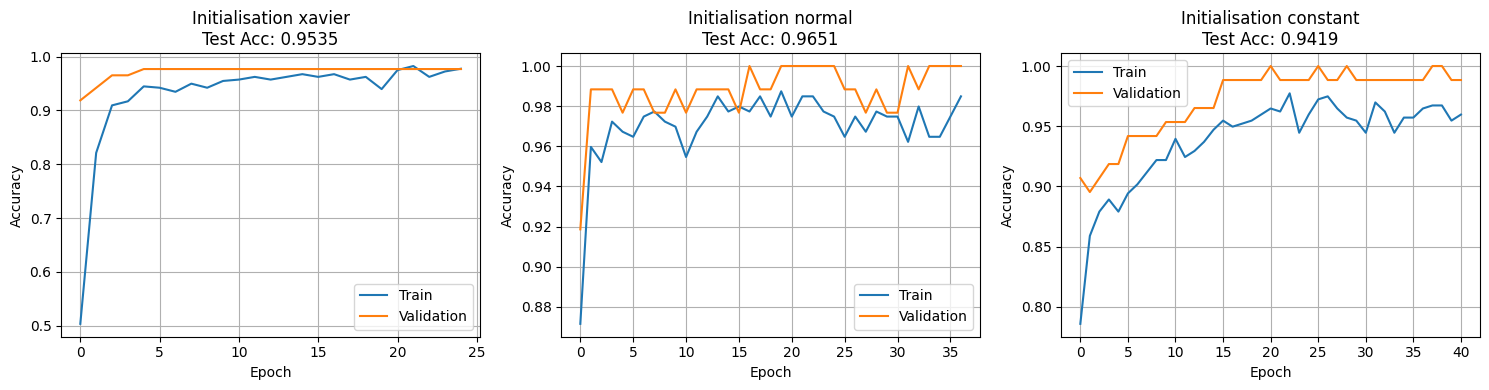

Epoch 10/100 | Train Loss: 0.1311 | Train Acc: 0.9723 | Val Loss: 0.0866 | Val Acc: 0.9884
Epoch 20/100 | Train Loss: 0.1033 | Train Acc: 0.9698 | Val Loss: 0.0548 | Val Acc: 0.9884
Epoch 30/100 | Train Loss: 0.0898 | Train Acc: 0.9723 | Val Loss: 0.0356 | Val Acc: 0.9884
Early stopping à l'époque 34
Modèle sauvegardé dans 'best_mlp_model.pth'
Modèle chargé avec succès!

ÉVALUATION FINALE - Breast Cancer Wisconsin
Accuracy:  0.9535
Precision: 0.9808
Recall:    0.9444
F1-Score:  0.9623

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.97      0.94        32
      benign       0.98      0.94      0.96        54

    accuracy                           0.95        86
   macro avg       0.95      0.96      0.95        86
weighted avg       0.96      0.95      0.95        86



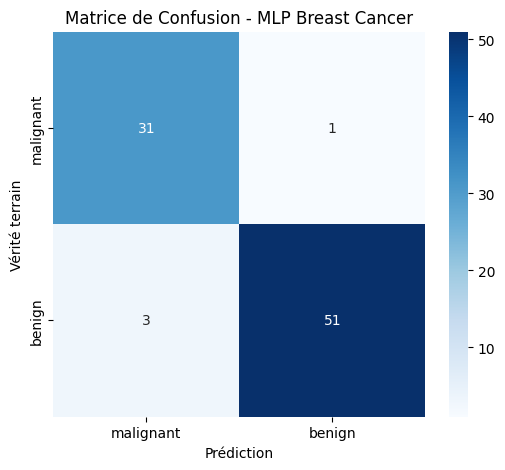


INSPECTION DES PARAMÈTRES DU MODÈLE

network.0.weight:
  Shape: torch.Size([64, 30])
  Mean: 0.000963
  Std: 0.146581
  Min: -0.328429
  Max: 0.317435

network.0.bias:
  Shape: torch.Size([64])
  Mean: -0.000243
  Std: 0.002511
  Min: -0.007331
  Max: 0.005031

network.1.weight:
  Shape: torch.Size([64])
  Mean: 1.000472
  Std: 0.042694
  Min: 0.916556
  Max: 1.111109

network.1.bias:
  Shape: torch.Size([64])
  Mean: -0.002023
  Std: 0.045611
  Min: -0.102046
  Max: 0.090046

network.4.weight:
  Shape: torch.Size([32, 64])
  Mean: -0.007113
  Std: 0.147322
  Min: -0.341040
  Max: 0.313499

network.4.bias:
  Shape: torch.Size([32])
  Mean: -0.000457
  Std: 0.002066
  Min: -0.005712
  Max: 0.004394

network.5.weight:
  Shape: torch.Size([32])
  Mean: 1.093242
  Std: 0.054333
  Min: 0.958655
  Max: 1.178201

network.5.bias:
  Shape: torch.Size([32])
  Mean: 0.070508
  Std: 0.054417
  Min: -0.047673
  Max: 0.162551

network.8.weight:
  Shape: torch.Size([2, 32])
  Mean: -0.002923
  Std: 

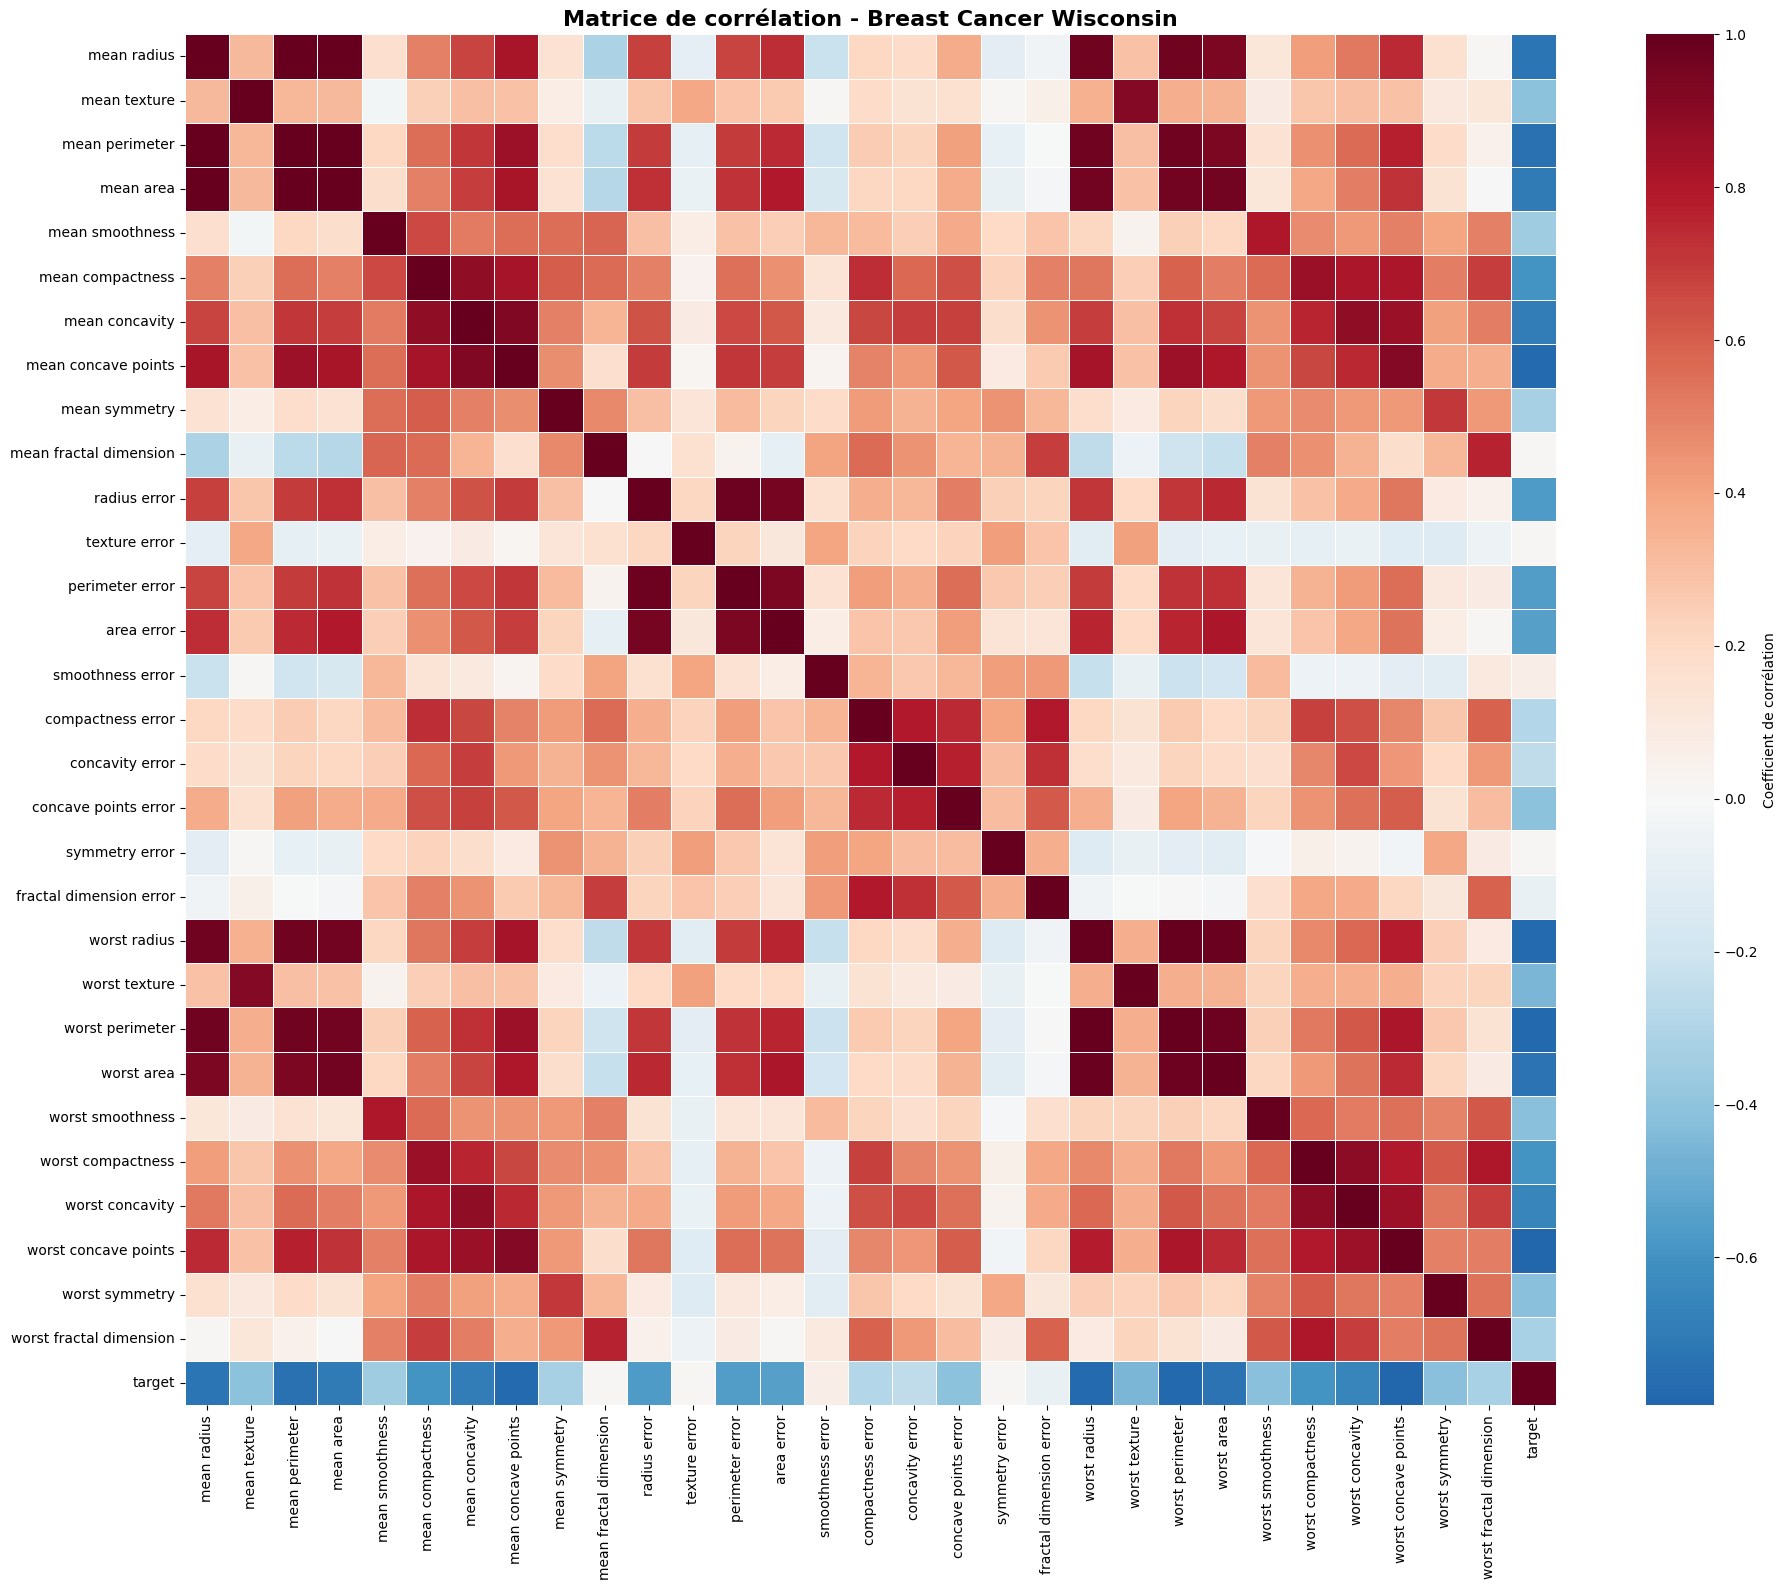


CORRÉLATIONS DES FEATURES AVEC LA CLASSE CIBLE

📈 Top 10 corrélations positives (bénin):
  smoothness error          : +0.067
  mean fractal dimension    : +0.013
  texture error             : +0.008
  symmetry error            : +0.007
  fractal dimension error   : -0.078
  concavity error           : -0.254
  compactness error         : -0.293
  worst fractal dimension   : -0.324
  mean symmetry             : -0.330
  mean smoothness           : -0.359

📉 Top 10 corrélations négatives (malin):
  worst concavity           : -0.660
  mean concavity            : -0.696
  mean area                 : -0.709
  mean radius               : -0.730
  worst area                : -0.734
  mean perimeter            : -0.743
  worst radius              : -0.776
  mean concave points       : -0.777
  worst perimeter           : -0.783
  worst concave points      : -0.794


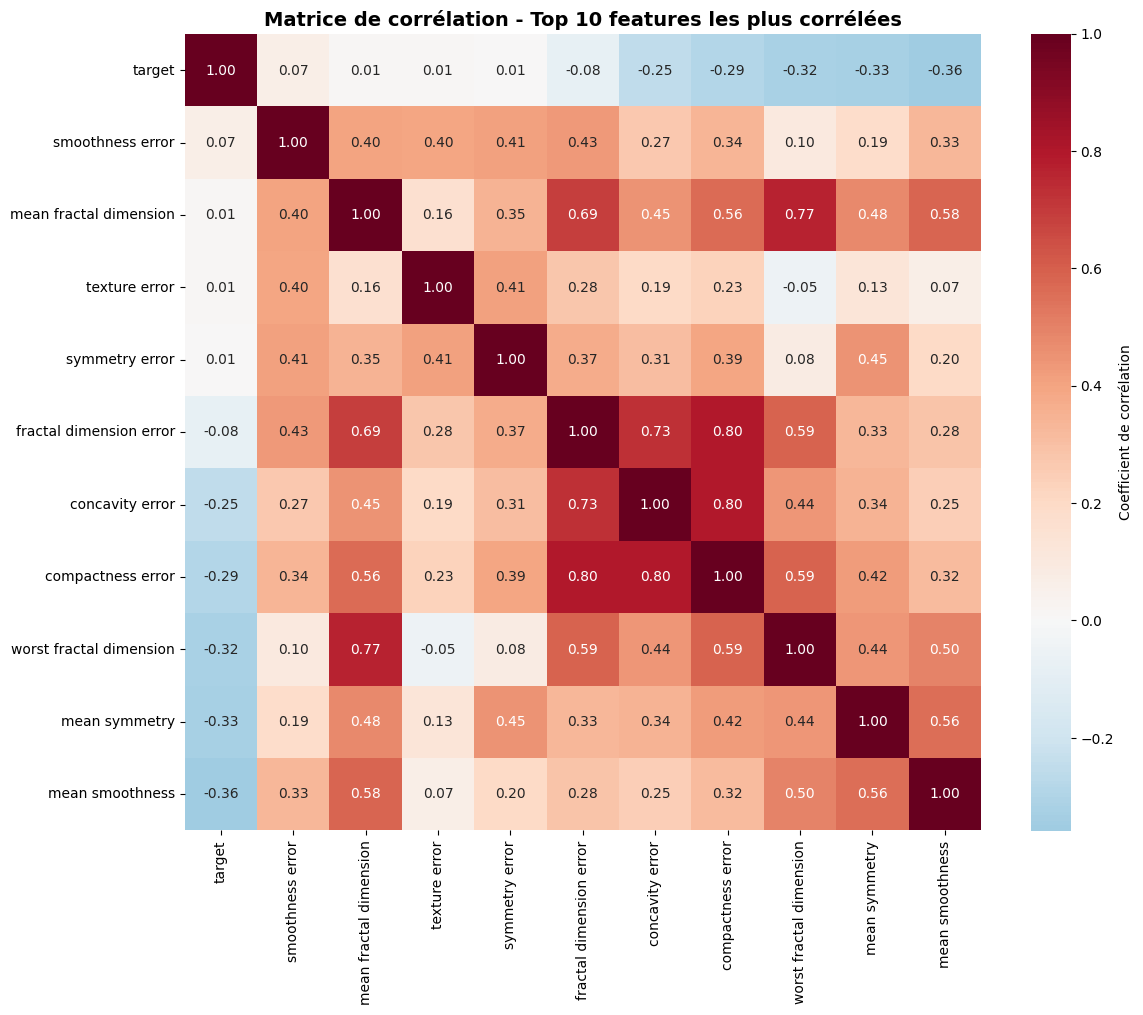

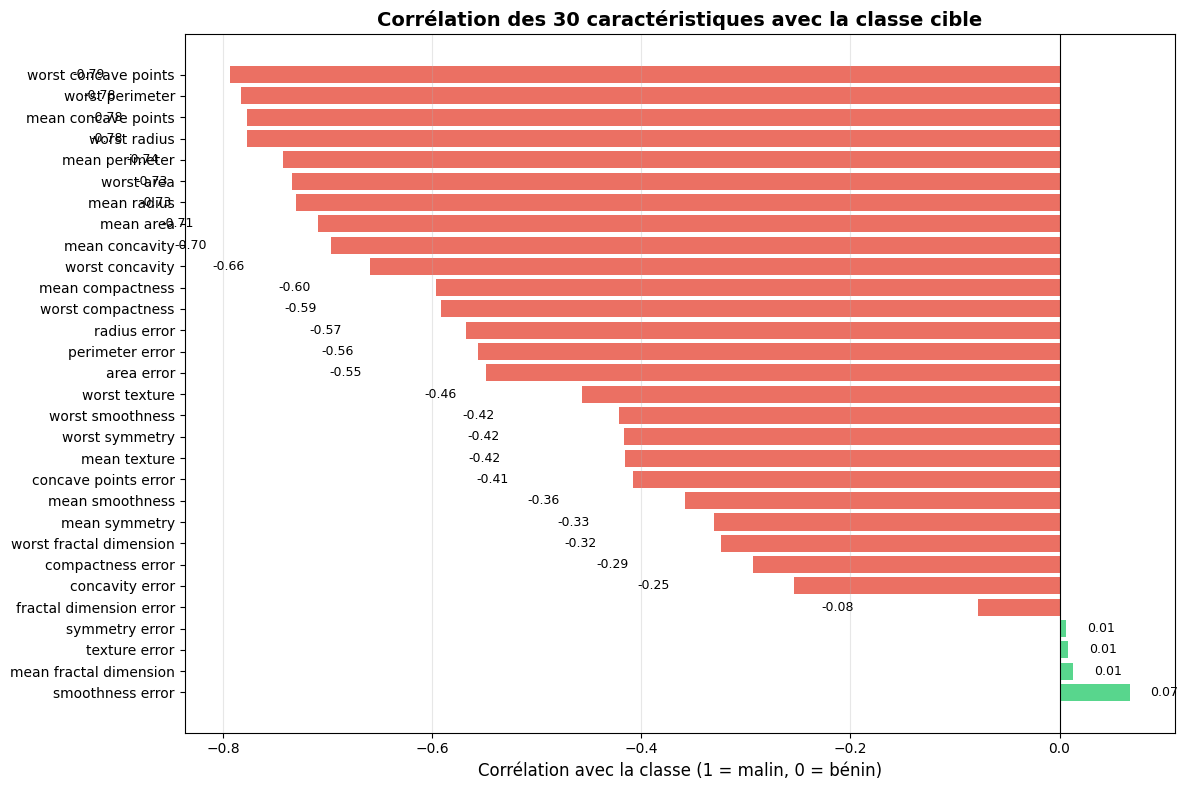


✅ Matrice de corrélation sauvegardée dans 'static/correlation_analysis.png'
✅ Données de corrélation sauvegardées dans 'static/correlation_data.json'


In [ ]:
# -*- coding: utf-8 -*-
# partie1_mlp_breast_cancer.ipynb

# %% [markdown]
# # PARTIE I - MLP : Classification sur Breast Cancer Wisconsin
# ## Deep Learning - EMSI 2025-2026

# %% [markdown]
# ### 1. Import des bibliothèques

# %%
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Vérification GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé: {device}")

# %% [markdown]
# ### 2. Chargement et préparation des données

# %%
# Chargement du dataset
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Classes: {data.target_names}")
print(f"Distribution: {np.bincount(y)}")

# %%
# Split en train/val/test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)
# 0.176 * 0.85 ≈ 0.15 pour validation

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# %%
# Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Conversion en tenseurs PyTorch
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Nombre de batches train: {len(train_loader)}")

# %% [markdown]
# ### 3. Implémentation des MLP

# %%
# Version 1: MLP avec nn.Sequential
class MLPSequential(nn.Module):
    def __init__(self, input_dim=30, hidden_dims=[64, 32], output_dim=2, dropout=0.2):
        super(MLPSequential, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# %%
# Version 2: MLP avec classe personnalisée (plus de contrôle)
class MLPCustom(nn.Module):
    def __init__(self, input_dim=30, hidden_dims=[64, 32], output_dim=2, dropout=0.2):
        super(MLPCustom, self).__init__()
        
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.bn1 = nn.BatchNorm1d(hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.bn2 = nn.BatchNorm1d(hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], output_dim)
        
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
        # Initialisation Xavier
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# %% [markdown]
# ### 4. Fonctions d'entraînement et d'évaluation

# %%
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device, patience=20):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        if patience_counter >= patience:
            print(f"Early stopping à l'époque {epoch+1}")
            break
    
    model.load_state_dict(best_model_state)
    return model, history

# %% [markdown]
# ### 5. Test des stratégies d'initialisation

# %%
def test_initializations():
    init_strategies = {
        'xavier': lambda m: nn.init.xavier_uniform_(m.weight) if hasattr(m, 'weight') and not isinstance(m, nn.BatchNorm1d) else None,
        'normal': lambda m: nn.init.normal_(m.weight, mean=0, std=0.01) if hasattr(m, 'weight') and not isinstance(m, nn.BatchNorm1d) else None,
        'constant': lambda m: nn.init.constant_(m.weight, 0.1) if hasattr(m, 'weight') and not isinstance(m, nn.BatchNorm1d) and len(m.weight.shape) >= 2 else None
    }
    
    results = {}
    
    for init_name, init_func in init_strategies.items():
        print(f"\n--- Test initialisation {init_name} ---")
        
        model = MLPSequential().to(device)
        
        # Application de l'initialisation
        def apply_init(m):
            if isinstance(m, nn.Linear):
                if init_name == 'xavier':
                    nn.init.xavier_uniform_(m.weight)
                elif init_name == 'normal':
                    nn.init.normal_(m.weight, mean=0, std=0.01)
                elif init_name == 'constant':
                    nn.init.constant_(m.weight, 0.1)
                nn.init.zeros_(m.bias)
        
        model.apply(apply_init)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        model, history = train_model(model, train_loader, val_loader, criterion, optimizer, 50, device)
        
        _, test_acc, _, _ = evaluate(model, test_loader, criterion, device)
        results[init_name] = {
            'best_val_acc': max(history['val_acc']),
            'test_acc': test_acc,
            'history': history
        }
        
        print(f"Meilleure accuracy validation: {results[init_name]['best_val_acc']:.4f}")
        print(f"Accuracy test: {test_acc:.4f}")
    
    return results

# Exécution
init_results = test_initializations()

# %% [markdown]
# ### 6. Visualisation des résultats d'initialisation

# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (init_name, result) in enumerate(init_results.items()):
    history = result['history']
    axes[idx].plot(history['train_acc'], label='Train')
    axes[idx].plot(history['val_acc'], label='Validation')
    axes[idx].set_title(f"Initialisation {init_name}\nTest Acc: {result['test_acc']:.4f}")
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].legend()
    axes[idx].grid(True)

plt.tight_layout()
plt.savefig('initialization_comparison.png', dpi=150)
plt.show()

# %% [markdown]
# ### 7. Sauvegarde et chargement du modèle

# %%
# Meilleur modèle avec Xavier
best_model = MLPSequential().to(device)

def apply_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

best_model.apply(apply_xavier)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_model.parameters(), lr=0.001)

best_model, history = train_model(best_model, train_loader, val_loader, criterion, optimizer, 100, device)

# Sauvegarde
torch.save({
    'model_state_dict': best_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scaler': scaler,
    'history': history,
    'best_val_acc': max(history['val_acc'])
}, 'best_mlp_model.pth')

print("Modèle sauvegardé dans 'best_mlp_model.pth'")

# Chargement
checkpoint = torch.load('best_mlp_model.pth', map_location=device)
loaded_model = MLPSequential().to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
print("Modèle chargé avec succès!")

# %% [markdown]
# ### 8. Évaluation finale complète

# %%
_, test_loss, test_preds, test_labels = evaluate(best_model, test_loader, criterion, device)

# Métriques
accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)

print("\n" + "="*50)
print("ÉVALUATION FINALE - Breast Cancer Wisconsin")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=data.target_names))

# Matrice de confusion
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Matrice de Confusion - MLP Breast Cancer')
plt.ylabel('Vérité terrain')
plt.xlabel('Prédiction')
plt.savefig('confusion_matrix_mlp.png', dpi=150)
plt.show()

# %% [markdown]
# ### 9. Inspection des paramètres

# %%
print("\n" + "="*50)
print("INSPECTION DES PARAMÈTRES DU MODÈLE")
print("="*50)

for name, param in best_model.named_parameters():
    print(f"\n{name}:")
    print(f"  Shape: {param.shape}")
    print(f"  Mean: {param.data.mean().item():.6f}")
    print(f"  Std: {param.data.std().item():.6f}")
    print(f"  Min: {param.data.min().item():.6f}")
    print(f"  Max: {param.data.max().item():.6f}")

print("\nstate_dict keys:")
print(best_model.state_dict().keys())

# %% [markdown]
# ### 10. Question de synthèse
# 
# **Question : Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard de la structure statistique des données étudiées ?**
# 
# *Réponse à rédiger dans le rapport en articulant théorie, choix méthodologiques, résultats expérimentaux et analyse critique.*

# %% 
# Sauvegarde du meilleur modèle à la fin de la Partie 1
# Récupération des noms de features depuis le dataset original
feature_names = data.feature_names.tolist()
target_names = data.target_names.tolist()

# Sauvegarde avec le bon modèle (best_model)
torch.save({
    'model_state_dict': best_model.state_dict(),
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'feature_names': feature_names,
    'target_names': target_names,
    'history': history,
    'best_val_acc': max(history['val_acc'])
}, 'mlp_model.pth')

print("Modèle sauvegardé avec succès dans 'mlp_model.pth'")
print(f"Meilleure accuracy de validation: {max(history['val_acc']):.4f}")
# -*- coding: utf-8 -*-
# CELLULE À AJOUTER DANS LE NOTEBOOK PARTIE 1
# Matrice de corrélation - Breast Cancer Wisconsin

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
import os

# Chargement des données
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# === 1. MATRICE DE CORRÉLATION COMPLÈTE ===
plt.figure(figsize=(20, 16))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Coefficient de corrélation'},
            square=True, linewidths=0.5)
plt.title('Matrice de corrélation - Breast Cancer Wisconsin', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix_full.png', dpi=150, bbox_inches='tight')
plt.show()

# === 2. CORRÉLATIONS AVEC LA TARGET ===
target_corr = corr_matrix['target'].sort_values(ascending=False)

print("\n" + "="*60)
print("CORRÉLATIONS DES FEATURES AVEC LA CLASSE CIBLE")
print("="*60)
print("\n📈 Top 10 corrélations positives (bénin):")
for feature, corr in target_corr.head(11).items():
    if feature != 'target':
        print(f"  {feature:25s} : {corr:+.3f}")

print("\n📉 Top 10 corrélations négatives (malin):")
for feature, corr in target_corr.tail(10).items():
    print(f"  {feature:25s} : {corr:+.3f}")

# === 3. HEATMAP DES TOP FEATURES ===
top_features = target_corr.head(11).index.tolist()  # Top 10 + target
top_corr = corr_matrix.loc[top_features, top_features]

plt.figure(figsize=(12, 10))
sns.heatmap(top_corr, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True,
            cbar_kws={'label': 'Coefficient de corrélation'})
plt.title('Matrice de corrélation - Top 10 features les plus corrélées', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix_top10.png', dpi=150, bbox_inches='tight')
plt.show()

# === 4. BARPLOT DES CORRÉLATIONS ===
plt.figure(figsize=(12, 8))
target_corr_clean = target_corr.drop('target')
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr_clean.values]

bars = plt.barh(target_corr_clean.index, target_corr_clean.values, color=colors, alpha=0.8)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Corrélation avec la classe (1 = malin, 0 = bénin)', fontsize=12)
plt.title('Corrélation des 30 caractéristiques avec la classe cible', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs
for bar, (idx, val) in zip(bars, target_corr_clean.items()):
    plt.text(val + 0.02 if val >= 0 else val - 0.15, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('correlation_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

# === 5. SAUVEGARDE POUR L'APPLICATION FLASK ===
# Créer le dossier static s'il n'existe pas
os.makedirs('static', exist_ok=True)

# Sauvegarder les images pour l'app Flask
plt.figure(figsize=(16, 12))
sns.heatmap(top_corr, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True,
            cbar_kws={'label': 'Coefficient de corrélation'})
plt.title('Matrice de corrélation - Top 10 features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('static/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.close()

# Sauvegarder les données de corrélation
correlation_data = {
    'top_positive': {k: float(v) for k, v in target_corr_clean.head(5).items()},
    'top_negative': {k: float(v) for k, v in target_corr_clean.tail(5).items()},
    'correlation_matrix': corr_matrix.to_dict()
}

import json
with open('static/correlation_data.json', 'w') as f:
    json.dump(correlation_data, f, indent=2)

print("\n✅ Matrice de corrélation sauvegardée dans 'static/correlation_analysis.png'")
print("✅ Données de corrélation sauvegardées dans 'static/correlation_data.json'")